# 03 — Quantile regression baseline

**Goal.** Predict a **price band**, not a single number: P10, P50, P90 of the
3-day-ahead BTC price. Output looks like *"in 3 days BTC will be ~$87,200,
with 80% probability the actual price lands between $84,500 and $89,500."*

**Why a band, not a point estimate?**
A single number lies about confidence. The same model can be very sure
(market calm) or very unsure (FOMC week) — a point estimate doesn't show
the difference. Quantile regression trains three separate models, one each
for the 10th, 50th, and 90th percentile of the predicted distribution. The
gap between P10 and P90 is the model's own admission of uncertainty.

**Why XGBoost?**
- Fast (trains in seconds, not minutes).
- Tabular data, ~40 features, 2000 rows — tree models dominate this regime.
- Supports `reg:quantileerror` natively (one-line objective swap).
- Transformer would need 10× more data + GPU + careful regularization to
  match an XGBoost baseline on this size dataset. Start simple.


loaders ready: load_dataset drop_indicator_warmup add_derived_features label_regression label_classification feature_columns
after warmup cut: (2072, 47) | 2020-04-30 → 2025-12-31
after derived features + dropna: (1982, 65)
rows: 1979    H = 3 days ahead
y_logret  mean=+0.0034  std=0.0519  min=-0.272  max=+0.209


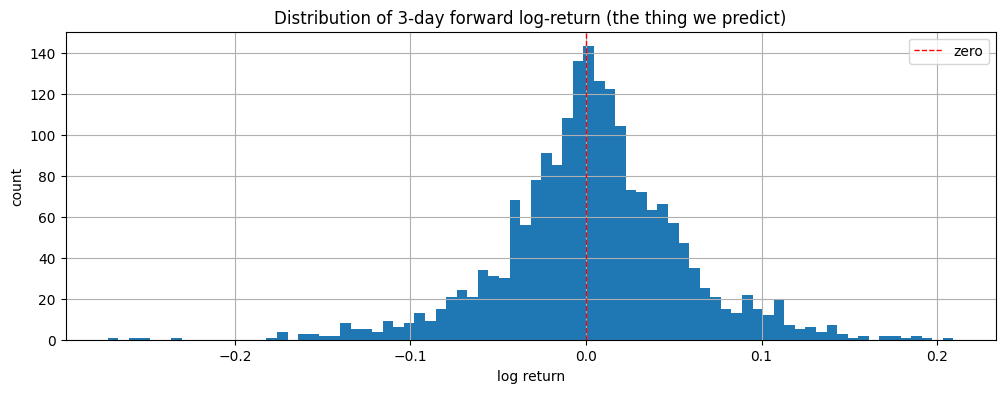

62 features used by the model:
['open', 'high', 'low', 'close', 'volume', 'ad_line', 'adx', 'atr', 'bollinger_lower', 'bollinger_middle', 'bollinger_upper', 'cci', 'ema', 'ichimoku_chikou_span', 'ichimoku_kijun', 'ichimoku_senkou_a', 'ichimoku_senkou_b', 'ichimoku_tenkan', 'keltner_lower', 'keltner_middle', 'keltner_upper', 'macd_histogram', 'macd_macd', 'macd_signal', 'momentum', 'obv', 'rsi', 'sma', 'stochastic_d', 'stochastic_k', 'volume_oscillator', 'vwap', 'williams_r', 'hash_rate', 'difficulty', 'block_time', 'miner_reserves', 'miner_outflows', 'mpi', 'exchange_inflow', 'exchange_outflow', 'exchange_reserves', 'events_in_window', 'high_impact_events_in_window', 'logret_1', 'logret_3', 'logret_5', 'logret_10', 'logret_20', 'vol_5', 'vol_20', 'vol_60', 'atr_pct', 'bb_width', 'kelt_width', 'px_vs_sma', 'sma_vs_ema', 'vol_z_20', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


In [1]:
%run 02_features_ablation.ipynb   # provides df, FEATS, H

## 3.1 — Time-based split

We split into **train / val / test / holdout** strictly by date:

| Split   | Range                      | Purpose                                |
|---------|----------------------------|----------------------------------------|
| train   | 2020-05-01 → 2024-12-31    | model fits gradients here              |
| val     | 2025-01-01 → 2025-09-30    | early stopping watches this loss       |
| test    | 2025-10-01 → 2025-12-31    | scored once; tells us out-of-sample skill |
| holdout | 2026 (separate CSV)        | scored once after everything is frozen |

**Critical rule for time-series ML: never shuffle.** If you randomly assign
rows to train/test, future rows leak into the training set and the model
"learns" things it could never know in deployment. The reported metrics
become a lie. Strict chronological cuts prevent this.

The `pd.Timestamp(..., tz="UTC")` keeps everything in UTC to match the
timestamps in the dataframe.


In [2]:
TRAIN_END = pd.Timestamp("2024-12-31", tz="UTC")
VAL_END   = pd.Timestamp("2025-09-30", tz="UTC")

tr = df[df["timestamp"] <= TRAIN_END]
va = df[(df["timestamp"] > TRAIN_END) & (df["timestamp"] <= VAL_END)]
te = df[df["timestamp"] > VAL_END]

print(f"train: {len(tr):4d}  {tr['timestamp'].min().date()} → {tr['timestamp'].max().date()}")
print(f"val:   {len(va):4d}  {va['timestamp'].min().date()} → {va['timestamp'].max().date()}")
print(f"test:  {len(te):4d}  {te['timestamp'].min().date()} → {te['timestamp'].max().date()}")
print(f"{len(FEATS)} features")


train: 1617  2020-06-29 → 2024-12-31
val:    273  2025-01-01 → 2025-09-30
test:    89  2025-10-01 → 2025-12-28
62 features


## 3.2 — Train the quantile triple

Three identical XGBoost regressors, only the `quantile_alpha` differs:

- `alpha=0.10` learns "the 10th percentile" — model trained to predict a
  value that the actual outcome exceeds ~90% of the time. = lower band.
- `alpha=0.50` learns the median (50th percentile). = central prediction.
- `alpha=0.90` learns the 90th percentile. = upper band.

Hyperparameter cheat-sheet (we used industry-default starting points):
- `max_depth=5` — each tree can split 5 times deep. Deeper = more
  capacity = more overfit risk.
- `n_estimators=800` — up to 800 trees. We stop early if val loss stops
  improving.
- `learning_rate=0.04` — how much each tree updates the prediction.
  Lower = slower learning, usually more accurate.
- `subsample=0.85` — each tree sees 85% of training rows. Adds randomness,
  reduces overfitting.
- `colsample_bytree=0.85` — each tree sees 85% of features. Same idea.
- `early_stopping_rounds=50` — stop if val loss doesn't improve for 50
  trees in a row.
- `tree_method="hist"` — faster training algorithm, marginal accuracy loss.


In [3]:
import xgboost as xgb

def train_q(alpha):
    m = xgb.XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=alpha,
        max_depth=5,
        n_estimators=800,
        learning_rate=0.04,
        subsample=0.85,
        colsample_bytree=0.85,
        tree_method="hist",
        early_stopping_rounds=50,
        verbosity=0,
    )
    m.fit(tr[FEATS], tr["y_logret"],
          eval_set=[(va[FEATS], va["y_logret"])], verbose=False)
    return m

m10 = train_q(0.10)
m50 = train_q(0.50)
m90 = train_q(0.90)
print("trained P10 / P50 / P90 models")


trained P10 / P50 / P90 models


## 3.3 — Predict + metrics

For each split we compute six numbers. Read them like this:

- **MAE_logret** — Mean Absolute Error of the median (P50) prediction in
  log-return space. Lower = better. Roughly: average prediction error in
  log-percent. 0.03 ≈ ~3% off on average.
- **naive_zero** — same MAE but for the dumbest possible model:
  "always predict 0% return". This is the random-walk baseline that any
  useful model must beat. If MAE ≥ naive_zero, the model has no signal.
- **cov80** — fraction of actual outcomes that fell *inside* the P10–P90
  band. The band advertises 80% coverage. Reality should be ~0.80.
  - 0.75–0.85 = well-calibrated
  - > 0.85 = too wide (model under-confident)
  - < 0.75 = too narrow (model over-confident, dangerous for risk sizing)
- **dir_acc** — did the sign of the prediction match the sign of the actual
  return? 0.50 = coin flip. 0.55+ = some directional skill.
- **price_MAE** — same as MAE_logret but in plain price terms (%).

`predict_band()` builds a result frame for each split with the raw inputs,
the three quantile predictions, and the reconstructed prices.
`np.exp(logret)` turns log-return back into a multiplier
(e.g. log=0.02 → exp(0.02)=1.0202 → +2.02% price move).


In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def predict_band(d):
    out = pd.DataFrame({
        "ts":       d["timestamp"].values,
        "now":      d["close"].values,          # close price on prediction day T
        "y_logret": d["y_logret"].values,       # true log-return T → T+H
        "p10":      m10.predict(d[FEATS]),
        "p50":      m50.predict(d[FEATS]),
        "p90":      m90.predict(d[FEATS]),
    })
    # Convert log-returns into prices for human-readable output.
    out["actual_price"] = out["now"] * np.exp(out["y_logret"])
    out["p10_price"]    = out["now"] * np.exp(out["p10"])
    out["p50_price"]    = out["now"] * np.exp(out["p50"])
    out["p90_price"]    = out["now"] * np.exp(out["p90"])
    return out

def report(name, b):
    mae   = mean_absolute_error(b["y_logret"], b["p50"])
    naive = mean_absolute_error(b["y_logret"], np.zeros(len(b)))
    rmse  = mean_squared_error(b["y_logret"], b["p50"]) ** 0.5
    cov80 = ((b["y_logret"] >= b["p10"]) & (b["y_logret"] <= b["p90"])).mean()
    dir_  = ((b["p50"] > 0) == (b["y_logret"] > 0)).mean()
    pxe   = (abs(b["actual_price"] - b["p50_price"]) / b["now"]).mean() * 100
    print(f"{name:6s}  MAE_logret={mae:.4f}  vs naive_zero={naive:.4f}  "
          f"RMSE={rmse:.4f}  band80_cov={cov80:.3f}  dir_acc={dir_:.3f}  "
          f"price_MAE={pxe:.2f}%")

band_va = predict_band(va)
band_te = predict_band(te)
report("VAL",  band_va)
report("TEST", band_te)


VAL     MAE_logret=0.0251  vs naive_zero=0.0254  RMSE=0.0342  band80_cov=0.908  dir_acc=0.502  price_MAE=2.51%
TEST    MAE_logret=0.0301  vs naive_zero=0.0305  RMSE=0.0386  band80_cov=0.854  dir_acc=0.528  price_MAE=2.97%


## 3.4 — Visualize the band (TEST set)

The plot shows three things over the TEST period:
- **Black line** — what actually happened (real BTC price 3 days after each
  prediction date).
- **Blue line** — the model's median prediction (P50).
- **Blue shaded area** — the 80% confidence band (P10 to P90).

What to look for:
- Black should stay inside the blue band most of the time (~80%).
- Median (blue line) tracking actuals = directional accuracy.
- Band that visibly widens during volatile periods + narrows during calm
  ones = the model is uncertainty-aware (good).
- Band that is the same width always = the quantile heads collapsed to
  near-constant offsets (bad — they're not learning regime).


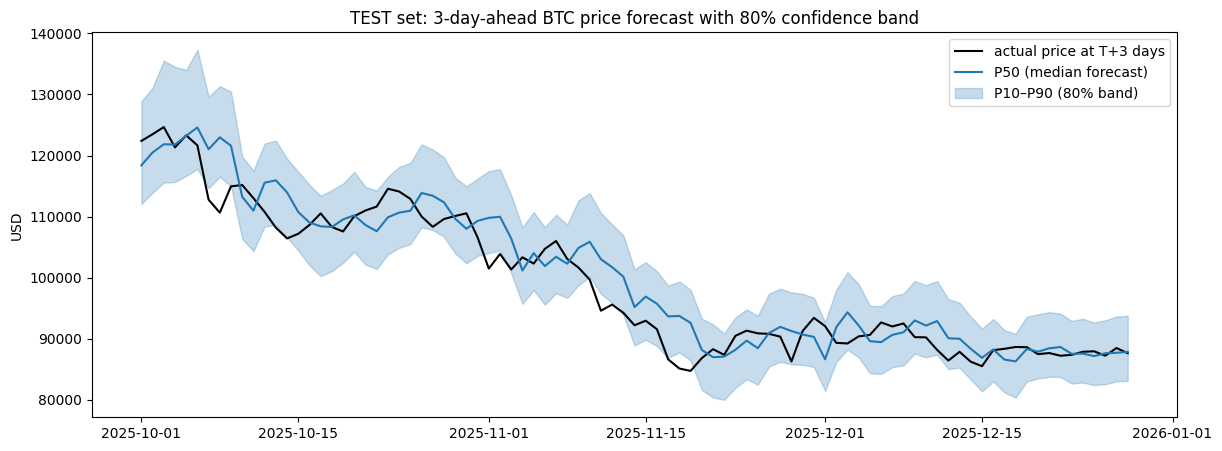

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(band_te["ts"], band_te["actual_price"],
        label="actual price at T+3 days", color="black", linewidth=1.5)
ax.plot(band_te["ts"], band_te["p50_price"],
        label="P50 (median forecast)", color="C0")
ax.fill_between(band_te["ts"], band_te["p10_price"], band_te["p90_price"],
                alpha=0.25, label="P10–P90 (80% band)", color="C0")
ax.set_title(f"TEST set: {H}-day-ahead BTC price forecast with 80% confidence band")
ax.set_ylabel("USD")
ax.legend()
plt.show()


## 3.5 — Feature importance (gain)

XGBoost can report how much each feature *contributed* to reducing loss
during training, summed over every tree it grew. We pull that for the P50
model and plot the top 20.

How to read it:
- High gain ≠ "this feature predicts the future". High gain = "the model
  used this feature a lot to split data during training".
- If `close` or `open` dominate, the model is mostly using price-level
  rather than indicators (a sign that indicators add little).
- If your engineered features (`logret_*`, `vol_*`, `bb_width`, …) sit in
  the top half, the engineering pulled its weight.


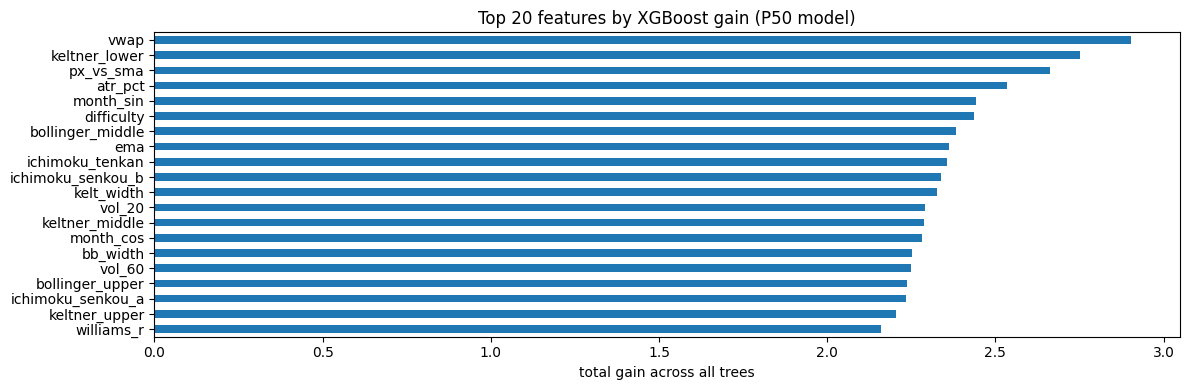

In [6]:
imp = pd.Series(m50.get_booster().get_score(importance_type="gain")).sort_values()
imp.tail(20).plot.barh(title="Top 20 features by XGBoost gain (P50 model)")
plt.xlabel("total gain across all trees")
plt.tight_layout()
plt.show()


## 3.6 — SHAP values: direction of each feature's effect

Feature importance tells you *which* features the model used. **SHAP**
tells you *how*: did high values of feature X push the prediction up or
down?

Each dot in the summary plot is one row from VAL. Color = the feature
value (red = high, blue = low). Horizontal position = how that feature
shifted the prediction for that row (right = up, left = down).

Reading example: if `rsi` shows red dots on the left, the model learned
"high RSI → bear (mean reversion)". If red on the right, the model learned
"high RSI → bull (momentum)". The plot tells you the model's internal
narrative.

SHAP is slow on the full set — we sample 500 rows from VAL to keep it
under a few seconds.


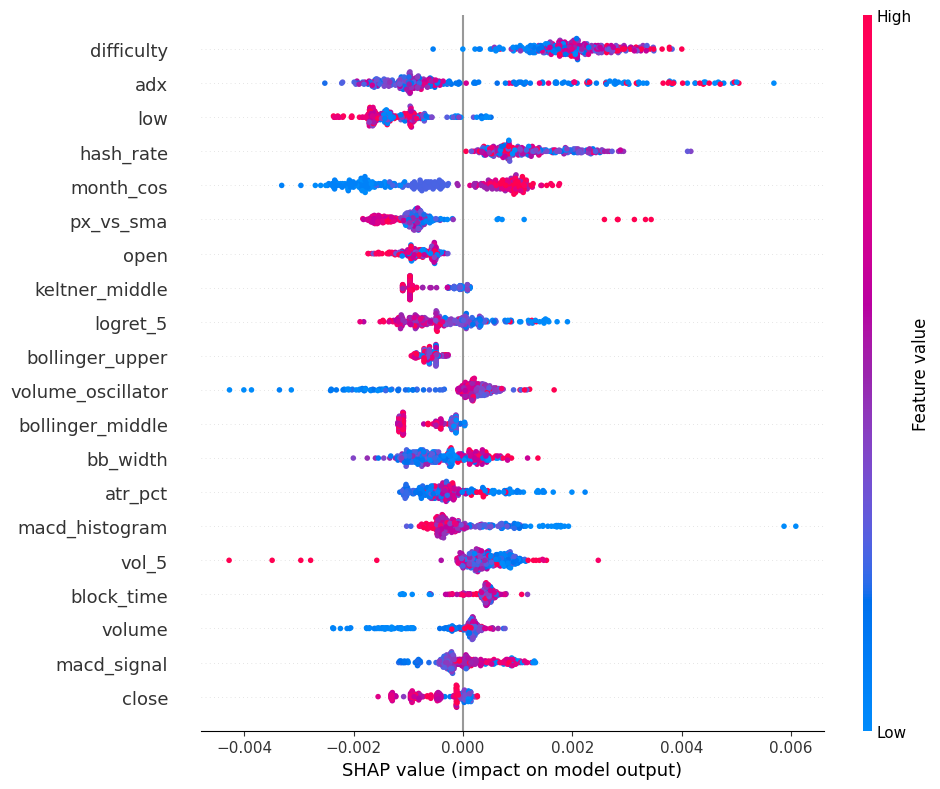

In [7]:
import shap

expl = shap.TreeExplainer(m50)
sample = va[FEATS].sample(min(500, len(va)), random_state=0)
sv = expl.shap_values(sample)

shap.summary_plot(sv, sample, plot_size=(10, 8))


## 3.7 — Sanity baselines

Two stupid models we should beat:

- **naive-zero**: always predict 0% return (assume no change). For
  high-noise series like BTC daily this is a surprisingly strong baseline.
  If our model can't beat it, we have no signal.
- **persistence**: predict that the next H days will return whatever the
  last 5 days returned (`logret_5`). This is the "trend continues" model.
  Usually awful at weekly horizons because mean-reversion kills it.


In [8]:
naive_te = np.zeros(len(te))
mae_naive = mean_absolute_error(te["y_logret"], naive_te)
print(f"naive-zero  MAE_logret={mae_naive:.4f}")

te2 = te.copy()
te2["persist"] = te2["logret_5"]    # cheap proxy: assume "last 5d return repeats"
mae_pers = mean_absolute_error(te2["y_logret"], te2["persist"])
print(f"persistence MAE_logret={mae_pers:.4f}")


naive-zero  MAE_logret=0.0305
persistence MAE_logret=0.0521


## 3.8 — 2026 holdout

The holdout CSV contains 2026 rows that were **never touched** during
training, validation, or test scoring. We load it now, apply the exact
same feature pipeline, and report metrics one time.

Why this matters: VAL and TEST guide hyperparameter choice — even if we
never explicitly tune on TEST, our human decisions are influenced by what
we saw. The 2026 holdout is the only number we should believe as a clean
out-of-sample estimate of the model's real-world performance.

If 2026 MAE_logret is much worse than TEST MAE_logret → the model is
overfit to 2025 patterns. If it's similar or better → the model
generalizes.

Note: the holdout starts March instead of January because
`add_derived_features` needs 60 prior days for `vol_60`. The first 60
rows of January–February become warmup. This is expected.


holdout rows: 85 range: 2026-03-02 → 2026-05-25
2026    MAE_logret=0.0253  vs naive_zero=0.0264  RMSE=0.0315  band80_cov=0.918  dir_acc=0.576  price_MAE=2.53%


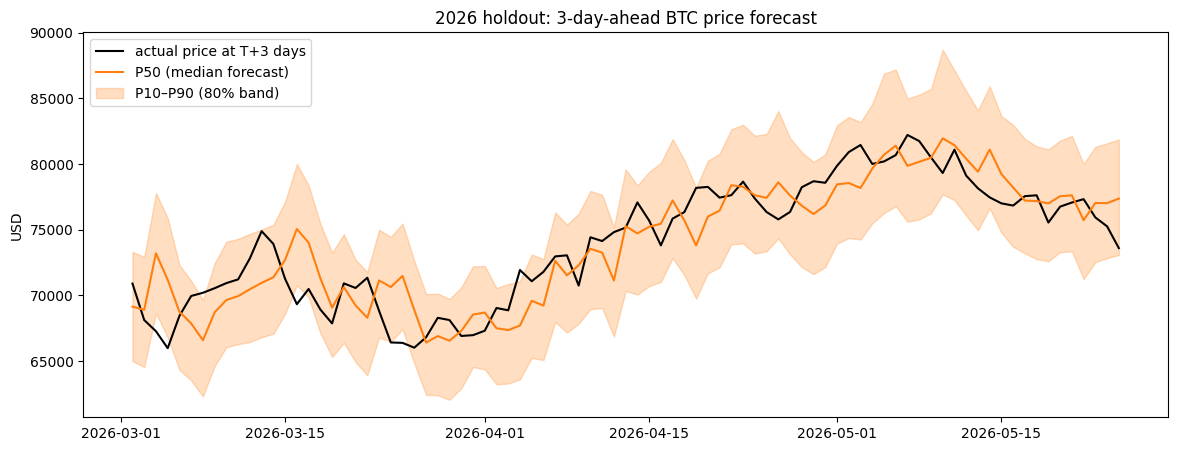

In [9]:
ho = load_dataset(HOLDOUT_CSV)
ho = add_derived_features(ho)
ho = ho.dropna().reset_index(drop=True)
ho = label_regression(ho, H=H)

print("holdout rows:", len(ho),
      "range:", ho["timestamp"].min().date(), "→", ho["timestamp"].max().date())

band_ho = predict_band(ho)
report("2026", band_ho)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(band_ho["ts"], band_ho["actual_price"],
        label="actual price at T+3 days", color="black", linewidth=1.5)
ax.plot(band_ho["ts"], band_ho["p50_price"], label="P50 (median forecast)", color="C1")
ax.fill_between(band_ho["ts"], band_ho["p10_price"], band_ho["p90_price"],
                alpha=0.25, label="P10–P90 (80% band)", color="C1")
ax.set_title(f"2026 holdout: {H}-day-ahead BTC price forecast")
ax.set_ylabel("USD")
ax.legend()
plt.show()


## 3.9 — Decision gate

Three checks before promoting this model into the production KFP pipeline:

1. **Skill** — TEST MAE_logret < naive-zero MAE_logret.
   If we lose to predict-zero, there's no signal worth shipping.

2. **Calibration** — VAL/TEST band80_cov ∈ [0.75, 0.85].
   The 80% band must actually cover ~80% of outcomes. Otherwise the
   uncertainty estimate is a lie and downstream risk decisions break.

3. **Generalization** — 2026 MAE ≤ TEST MAE + 0.01.
   The model must not collapse on data after the test period. A big gap
   = overfit to 2025 regime.

If all three pass → port `FEATS` and the quantile training loop into
`src/train/train.py`, swap the pipeline objective, ship to Phase 4.
If any fail → iterate features in 00/02. Do **not** jump to a transformer
just to chase a number — same features = same ceiling.
